In [1]:
### automatically refresh the buffer
%load_ext autoreload
%autoreload 2

### solve the auto-complete issue

%config Completer.use_jedi = False
%matplotlib inline

import warnings
warnings.filterwarnings('ignore')
warnings.simplefilter(action='ignore', category=FutureWarning)

### lvl 2 setups (systerm)
import os
import numpy as np
import pandas as pd
import xarray as xr

import matplotlib as mpl
import cartopy.crs as ccrs
import cartopy.feature as cfeature

import cartopy.feature as cfeature
from cartopy.mpl.ticker import LongitudeFormatter, LatitudeFormatter
from matplotlib.patches import Rectangle
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap,LinearSegmentedColormap,BoundaryNorm
import matplotlib.dates as mdates
import geopandas as gpd
from shapely.geometry import Point
from datetime import datetime
import h5py
import numpy as np
np.set_printoptions(suppress=True)

In [3]:
ds_ca = xr.open_dataset('/data/ggong/CALIPSO/Dustprof/ENA_annual/merge_06-21_5x5.nc').sel(time=slice("2006-01-01", "2017-12-31"))
# ds_cs = xr.open_dataset('/data/ggong/CloudSat/merge_nc/ENA_merge5.nc')
ds_md = xr.open_dataset('/data/ggong/MODIS/ENA_COD_merge_5x5.nc').sel(time=slice("2006-01-01", "2017-12-31"))

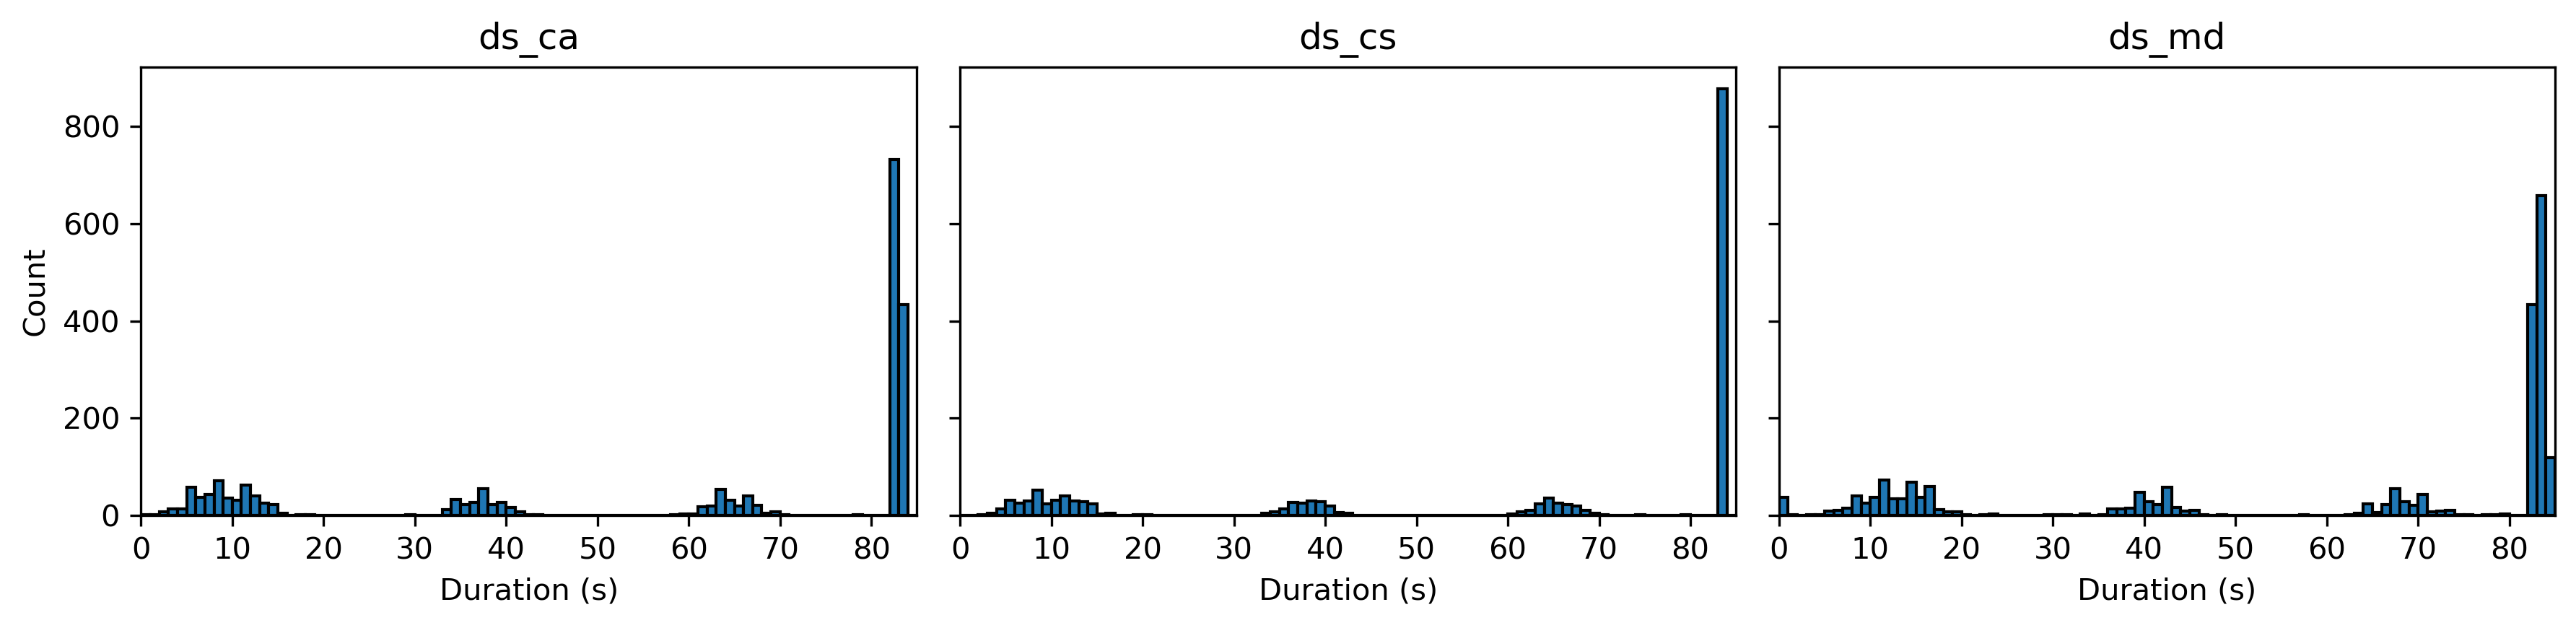

In [3]:
import numpy as np
import matplotlib.pyplot as plt

def get_duration(ds, thr=2.0):
    t = np.sort(ds.time.values.astype("datetime64[ns]"))
    dt = np.diff(t) / np.timedelta64(1, "s")
    seg, s = [], 0
    for i, ok in enumerate(dt <= thr):
        if not ok: seg.append((s, i)); s = i + 1
    seg.append((s, len(t)-1))
    return np.array([(t[j]-t[i]) / np.timedelta64(1,"s") for i,j in seg]).astype(int)

dur_ca, dur_cs, dur_md = get_duration(ds_ca), get_duration(ds_cs), get_duration(ds_md)

all_dur = np.concatenate([dur_ca, dur_cs, dur_md])
xmin, xmax = all_dur.min(), all_dur.max()
bins = np.arange(xmin, xmax + 2)
xticks = np.arange(xmin, xmax + 1,10)

fig, ax = plt.subplots(1, 3, figsize=(12,3), sharey=True, dpi=300)

for d, a, name in zip([dur_ca, dur_cs, dur_md], ax, ["ds_ca","ds_cs","ds_md"]):
    a.hist(d, bins=bins, edgecolor="k")
    a.set_xlim(xmin, xmax+1)
    a.set_xticks(xticks)
    a.set_title(name)
    a.set_xlabel("Duration (s)")

ax[0].set_ylabel("Count")
plt.tight_layout()
plt.show()


In [4]:
import numpy as np

def get_events(ds, thr=2.0):
    t = np.sort(ds.time.values.astype("datetime64[ns]"))
    dt = np.diff(t) / np.timedelta64(1, "s")
    seg, s = [], 0
    for i, ok in enumerate(dt <= thr):
        if not ok: seg.append((s, i)); s = i + 1
    seg.append((s, len(t) - 1))
    return np.array([(t[i], t[j]) for i, j in seg], dtype="datetime64[ns]")

def _dist(a0,a1,b0,b1):
    if (b1 >= a0) and (b0 <= a1): return np.timedelta64(0,"ns")
    if b1 < a0: return a0 - b1
    return b0 - a1

def count_event_matches(A, B, tol_s=120):
    tol = np.timedelta64(int(tol_s*1e9), "ns")
    A_hit = np.zeros(len(A), bool); B_hit = np.zeros(len(B), bool); pair = 0
    for i,(a0,a1) in enumerate(A):
        m = (B[:,1] >= a0 - tol) & (B[:,0] <= a1 + tol)
        for j in np.where(m)[0]:
            if _dist(a0,a1,*B[j]) <= tol: pair += 1; A_hit[i]=1; B_hit[j]=1
    return A_hit.sum(), B_hit.sum(), pair

def matched_pairs(A, B, tol_s=120):
    tol = np.timedelta64(int(tol_s*1e9), "ns"); out = []
    for i,(a0,a1) in enumerate(A):
        m = (B[:,1] >= a0 - tol) & (B[:,0] <= a1 + tol)
        if not np.any(m): continue
        js = np.where(m)[0]
        d = np.array([_dist(a0,a1,*B[j]) for j in js])
        j = js[np.argmin(d)]
        if d.min() <= tol: out.append((i, j, float(d.min()/np.timedelta64(1,"s"))))
    return out

def matched_triples(A, B, C, tol_s=120):  # A锚点：给每个A找最近B和最近C，并要求B-C也在tol内
    AB = matched_pairs(A, B, tol_s); AC = matched_pairs(A, C, tol_s)
    b_of = {i:j for i,j,_ in AB}; c_of = {i:k for i,k,_ in AC}
    tol = np.timedelta64(int(tol_s*1e9), "ns"); triples = []
    for i in set(b_of) & set(c_of):
        j, k = b_of[i], c_of[i]
        a0,a1 = A[i]; b0,b1 = B[j]; c0,c1 = C[k]
        if _dist(b0,b1,c0,c1) <= tol:
            gap = max(_dist(a0,a1,b0,b1), _dist(a0,a1,c0,c1), _dist(b0,b1,c0,c1))
            triples.append((i, j, k, float(gap/np.timedelta64(1,"s"))))
    return triples

# ===== 1) events =====
ev_ca = get_events(ds_ca, 2.0)
ev_cs = get_events(ds_cs, 2.0)
ev_md = get_events(ds_md, 2.0)

print("CA events:", len(ev_ca), "CS events:", len(ev_cs), "MD events:", len(ev_md))

# ===== 2) pairwise match stats (tol=120s) =====
for X, Y, nX, nY in [(ev_ca, ev_cs, "CA", "CS"), (ev_ca, ev_md, "CA", "MD"), (ev_cs, ev_md, "CS", "MD")]:
    xhit, yhit, npair = count_event_matches(X, Y, tol_s=120)
    print(f"{nX}-{nY}: {nX} matched {xhit}/{len(X)}, {nY} matched {yhit}/{len(Y)}, pairs={npair}")

# ===== 3) triple matches (CA as anchor) =====
triples = matched_triples(ev_ca, ev_cs, ev_md, tol_s=120)
print("Triple matches (CA-CS-MD):", len(triples))
# triples: (i_ca, j_cs, k_md, max_gap_seconds)


CA events: 2091 CS events: 1556 MD events: 2228
CA-CS: CA matched 1553/2091, CS matched 1552/1556, pairs=1553
CA-MD: CA matched 1937/2091, MD matched 1968/2228, pairs=1969
CS-MD: CS matched 1284/1556, MD matched 1299/2228, pairs=1299
Triple matches (CA-CS-MD): 1283


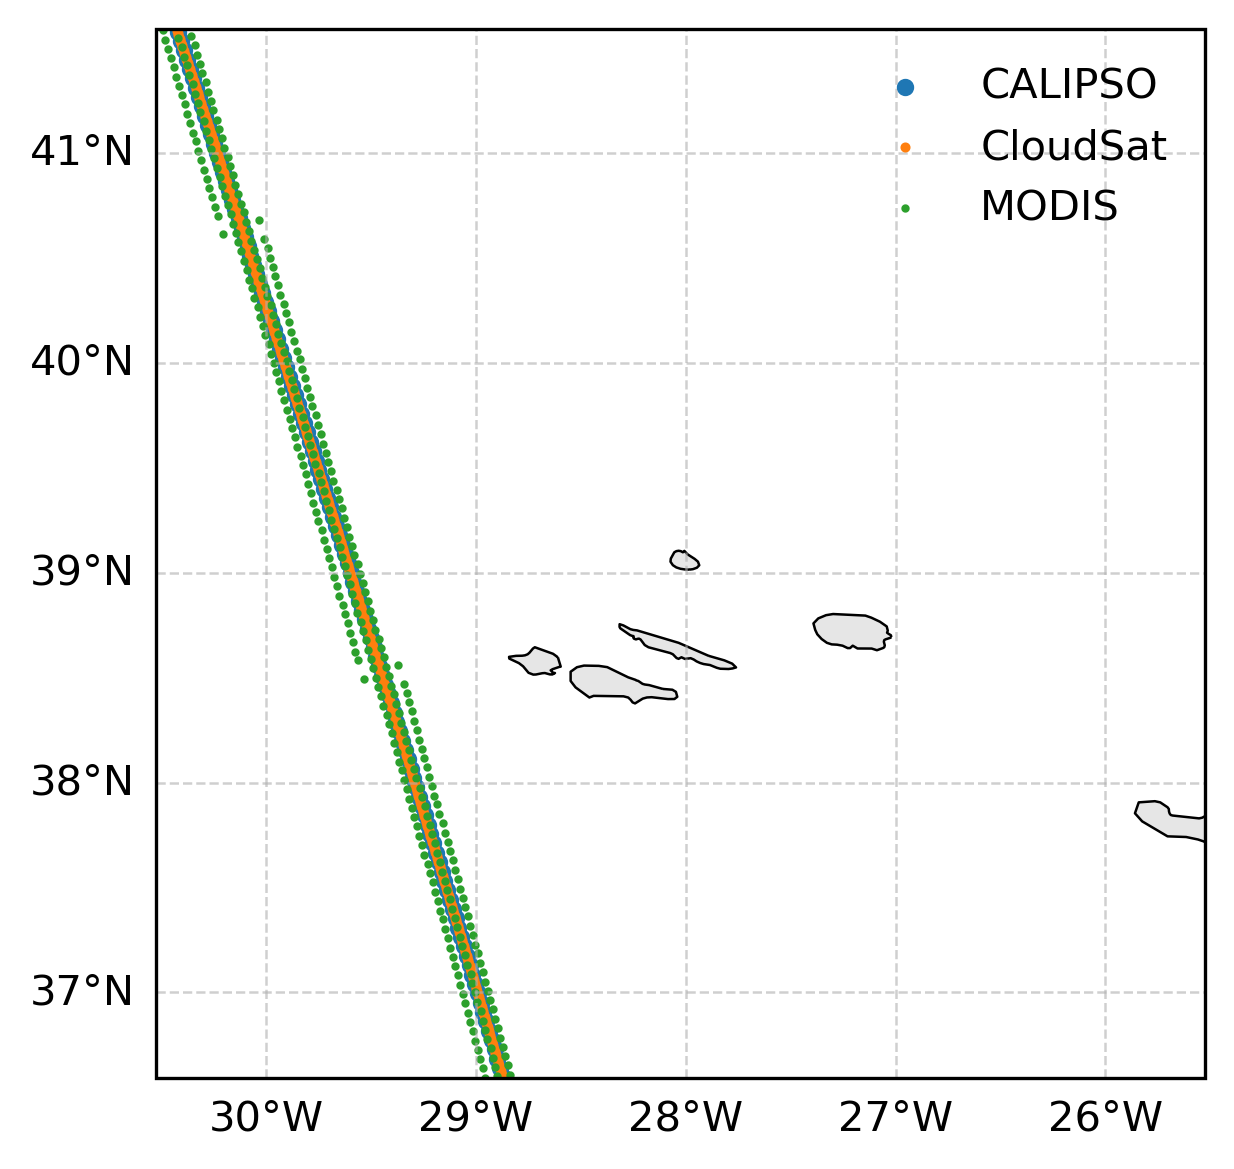

In [5]:
import numpy as np
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import matplotlib.ticker as mticker
from cartopy.mpl.gridliner import LONGITUDE_FORMATTER, LATITUDE_FORMATTER

ENA = (36.5916, 41.5916, -30.5257, -25.5257)
lat0, lat1, lon0, lon1 = ENA

i_ca, j_cs, k_md, gap = triples[20]
a0,a1 = ev_ca[i_ca]; b0,b1 = ev_cs[j_cs]; c0,c1 = ev_md[k_md]
t0, t1 = min(a0,b0,c0), max(a1,b1,c1)
CA, CS, MD = (ds_ca.sel(time=slice(t0,t1)), ds_cs.sel(time=slice(t0,t1)), ds_md.sel(time=slice(t0,t1)))

def _lon180(x): return ((x+180)%360)-180
def _sc(ds, lab, s):
    lon = _lon180(np.asarray(ds["lon"]).astype(float)).ravel()
    lat = np.asarray(ds["lat"]).astype(float).ravel()
    m = np.isfinite(lon) & np.isfinite(lat)
    ax.scatter(lon[m], lat[m], s=s, transform=ccrs.PlateCarree(), label=lab)

fig = plt.figure(figsize=(5,4), dpi=300)
ax = plt.axes(projection=ccrs.PlateCarree())
ax.set_extent([lon0, lon1, lat0, lat1], crs=ccrs.PlateCarree())
ax.add_feature(cfeature.LAND, facecolor="0.9")
ax.add_feature(cfeature.COASTLINE, linewidth=0.6)

_sc(CA, "CALIPSO", 10); _sc(CS, "CloudSat", 2); _sc(MD, "MODIS", 1)

gl = ax.gridlines(crs=ccrs.PlateCarree(), draw_labels=True, linewidth=0.6, alpha=0.6, linestyle="--")
gl.top_labels = False; gl.right_labels = False
gl.xformatter = LONGITUDE_FORMATTER; gl.yformatter = LATITUDE_FORMATTER

ax.legend(frameon=False)
plt.tight_layout()
plt.show()


## Cloud and Dust pair select

### single layer warm cloud

### test for a single triple match cas

In [6]:
import numpy as np
import pandas as pd
from scipy.spatial import cKDTree

# ---------------------------
# helpers
# ---------------------------
def lon180(x): return ((x + 180) % 360) - 180

def xyz(lat, lon):
    lat, lon = np.deg2rad(lat), np.deg2rad(lon)
    return np.c_[np.cos(lat)*np.cos(lon), np.cos(lat)*np.sin(lon), np.sin(lat)]

def _prep_cs_global(ds_cs):
    """
    Precompute (global, aligned to ds_cs.time):
      - cs_single: (time,) bool  single-layer profile?
      - cs_base1d_km, cs_top1d_km: (time,) km
      - cs_Ttop_K: (time,) Temperature at cloud-top level (K), using zAGL=Height
    """
    # Cloud layers (km)
    base = ds_cs["CloudLayerBase"].values.astype(float)  # (time,10)
    top  = ds_cs["CloudLayerTop"].values.astype(float)   # (time,10)
    valid = np.isfinite(base) & np.isfinite(top) & (base > -90) & (top > -90)
    nlayer = valid.sum(axis=1)
    cs_single = (nlayer == 1)

    cs_base1d_km = np.nanmin(np.where(valid, base, np.nan), axis=1)
    cs_top1d_km  = np.nanmax(np.where(valid, top,  np.nan), axis=1)

    # Height/Temperature (m, m, K)
    H   = ds_cs["Height"].values.astype(float)          # (time,125) m
    z_agl = H 

    T = ds_cs["Temperature"].values.astype(float)       # (time,125) K

    # Temperature at (single-layer) cloud top: find nearest height level to top_m
    top_m = cs_top1d_km * 1000.0
    cs_Ttop_K = np.full(len(top_m), np.nan)
    good = np.isfinite(top_m)
    k = np.nanargmin(np.abs(z_agl[good] - top_m[good, None]), axis=1)
    cs_Ttop_K[good] = T[good, k]

    return cs_single, cs_base1d_km, cs_top1d_km, cs_Ttop_K

def _nearest_modis_cod(MD, ca_lat, ca_lon, k=3,
                       vars_need=("re_1621","re_1621_unc",
                                  "COD_1621","COD_1621_unc",
                                  "CWP_1621","CWP_1621_unc")):
    """
    For each CA point, find nearest k MODIS pixels and return mean-of-k for:
      - md_lat_mean, md_lon_mean
      - all vars in vars_need
    """
    md_lat = np.asarray(MD["lat"]).astype(float).ravel()
    md_lon = lon180(np.asarray(MD["lon"]).astype(float)).ravel()

    # require finite lat/lon to build tree
    m = np.isfinite(md_lat) & np.isfinite(md_lon)
    tree = cKDTree(xyz(md_lat[m], md_lon[m]))

    _, idx = tree.query(xyz(ca_lat, ca_lon), k=k)
    idx = np.atleast_2d(idx)  # (n_ca,k)

    out = {
        "md_lat_mean": np.nanmean(md_lat[m][idx], axis=1),
        "md_lon_mean": np.nanmean(md_lon[m][idx], axis=1),
    }

    for v in vars_need:
        arr = np.asarray(MD[v]).astype(float).ravel()
        arr = arr[m]
        out[v + "_mean"] = np.nanmean(arr[idx], axis=1)

    return out

def build_samples_for_triple(triple, ev_ca, ev_cs, ev_md, ds_ca, ds_cs, ds_md,
                             cs_single, cs_base1d_km, cs_top1d_km, cs_Ttop_K,
                             k_cs=5, warm_thr_K=273.15, low_thr_m=3000.0):
    """
    One row per CALIPSO point (sample) in this triple window.
    Rules:
      - fixed nearest k_cs CloudSat profiles; if any is not single-layer => invalid
      - mean cloud top (m) < low_thr_m
      - mean T_at_cloud_top (K) > warm_thr_K
      - nearest MODIS COD attached
    """
    i_ca, j_cs, k_md, gap = triple
    a0,a1 = ev_ca[i_ca]; b0,b1 = ev_cs[j_cs]; c0,c1 = ev_md[k_md]
    t0, t1 = min(a0,b0,c0), max(a1,b1,c1)

    CA = ds_ca.sel(time=slice(t0,t1))
    CS = ds_cs.sel(time=slice(t0,t1))
    MD = ds_md.sel(time=slice(t0,t1))

    ca_t   = CA.time.values
    ca_lat = np.asarray(CA["lat"]).astype(float).ravel()
    ca_lon = lon180(np.asarray(CA["lon"]).astype(float)).ravel()

    # CS subset -> global indices
    idx_cs_global = np.where((ds_cs.time.values >= t0) & (ds_cs.time.values <= t1))[0]

    cs_lat_w = np.asarray(CS["lat"]).astype(float).ravel()
    cs_lon_w = lon180(np.asarray(CS["lon"]).astype(float)).ravel()

    # Require at least 5 CS points in window to define "nearest 5"
    if len(cs_lat_w) < k_cs:
        return pd.DataFrame({
            "time": ca_t, "ca_lat": ca_lat, "ca_lon": ca_lon,
            "valid": np.zeros(len(ca_lat), bool),
            "reason": ["CS<5 in window"] * len(ca_lat),
        })

    # Nearest 5 CS to each CA point (fixed)
    tree_cs = cKDTree(xyz(cs_lat_w, cs_lon_w))
    _, nn = tree_cs.query(xyz(ca_lat, ca_lon), k=k_cs)
    nn = np.atleast_2d(nn)  # (n_ca,5)

    # Nearest MODIS COD
    md_near = _nearest_modis_cod(
        MD, ca_lat, ca_lon, k=3,
        vars_need=("re_1621","re_1621_unc",
                   "COD_1621","COD_1621_unc",
                   "CWP_1621","CWP_1621_unc")
    )

    ok_single5 = np.zeros(len(ca_lat), bool)
    top_mean_m = np.full(len(ca_lat), np.nan)
    base_mean_m = np.full(len(ca_lat), np.nan)
    Ttop_mean_K = np.full(len(ca_lat), np.nan)

    for p in range(len(ca_lat)):
        g = idx_cs_global[nn[p]]  # fixed 5 CS profiles (global indices)
        if np.all(cs_single[g]):
            ok_single5[p] = True
            top_mean_m[p]  = np.nanmean(cs_top1d_km[g] * 1000.0)
            base_mean_m[p] = np.nanmean(cs_base1d_km[g] * 1000.0)
            Ttop_mean_K[p] = np.nanmean(cs_Ttop_K[g])

    ok_low  = ok_single5 & (top_mean_m < low_thr_m)
    ok_warm = ok_single5 & (Ttop_mean_K > warm_thr_K)
    valid = ok_single5 & ok_low & ok_warm

    reason = np.where(~ok_single5, "not all 5 CS single",
             np.where(~(top_mean_m < low_thr_m), "top_mean>=3km",
             np.where(~(Ttop_mean_K > warm_thr_K), "Ttop_mean<=273.15K", "ok")))

    df = pd.DataFrame({
        "time": ca_t,
        "ca_lat": ca_lat, "ca_lon": ca_lon,
    
        # --- MODIS mean-of-3 nearest pixels ---
        "md_lat": md_near["md_lat_mean"],
        "md_lon": md_near["md_lon_mean"],
        "re_1621": md_near["re_1621_mean"],
        "re_1621_unc": md_near["re_1621_unc_mean"],
        "COD_1621": md_near["COD_1621_mean"],
        "COD_1621_unc": md_near["COD_1621_unc_mean"],
        "CWP_1621": md_near["CWP_1621_mean"],
        "CWP_1621_unc": md_near["CWP_1621_unc_mean"],
    
        "cs_base_mean_m": base_mean_m,
        "cs_top_mean_m": top_mean_m,
        "cs_Ttop_mean_K": Ttop_mean_K,
        "valid": valid,
        "reason": reason,
    })
    return df

# ---------------------------
# RUN
# ---------------------------
# 1) precompute once
cs_single, cs_base1d_km, cs_top1d_km, cs_Ttop_K = _prep_cs_global(ds_cs)

# 2) build sample table for one triple window (change index as needed)
df = build_samples_for_triple(
    triples[0], ev_ca, ev_cs, ev_md,
    ds_ca, ds_cs, ds_md,
    cs_single, cs_base1d_km, cs_top1d_km, cs_Ttop_K,
    k_cs=5, warm_thr_K=273.15, low_thr_m=3000.0
)

print(df.head())
print("Valid samples:", int(df["valid"].sum()), "/", len(df))
print(df["reason"].value_counts())


                           time     ca_lat     ca_lon     md_lat     md_lon  \
0 2006-06-14 04:03:04.349199778  41.578682 -27.752411  41.554323 -27.757151   
1 2006-06-14 04:03:05.093199717  41.534279 -27.766954  41.539224 -27.761520   
2 2006-06-14 04:03:05.836200111  41.489971 -27.781551  41.495430 -27.777980   
3 2006-06-14 04:03:06.580200049  41.445393 -27.796240  41.450878 -27.792725   
4 2006-06-14 04:03:07.324199988  41.401054 -27.810633  41.407857 -27.809489   

   re_1621  re_1621_unc  COD_1621  COD_1621_unc  CWP_1621  CWP_1621_unc  \
0      NaN          NaN       NaN           NaN       NaN           NaN   
1      NaN          NaN       NaN           NaN       NaN           NaN   
2      NaN          NaN       NaN           NaN       NaN           NaN   
3      NaN          NaN       NaN           NaN       NaN           NaN   
4      NaN          NaN       NaN           NaN       NaN           NaN   

   cs_base_mean_m  cs_top_mean_m  cs_Ttop_mean_K  valid               reas

In [7]:
import numpy as np
import xarray as xr
from scipy.spatial import cKDTree

# -------------------------
# helpers
# -------------------------
def lon180(x):
    return ((x + 180) % 360) - 180

def xyz(lat, lon):
    lat, lon = np.deg2rad(lat), np.deg2rad(lon)
    return np.c_[np.cos(lat)*np.cos(lon), np.cos(lat)*np.sin(lon), np.sin(lat)]

def prep_cs_global(ds_cs):
    """
    Precompute global per-profile arrays aligned to ds_cs.time:
      - cs_single (bool): single-layer profile?
      - cs_top1d_km (float): single-layer cloud top (km)
      - cs_Ttop_K (float): Temperature at cloud-top level (K), using zAGL = Height
    """
    base = ds_cs["CloudLayerBase"].values.astype(float)  # (t, 10) km
    top  = ds_cs["CloudLayerTop"].values.astype(float)   # (t, 10) km
    valid = np.isfinite(base) & np.isfinite(top) & (base > -90) & (top > -90)
    nlayer = valid.sum(axis=1)
    cs_single = (nlayer == 1)

    top1d_km = np.nanmax(np.where(valid, top, np.nan), axis=1)  # (t,)

    H   = ds_cs["Height"].values.astype(float)                 # (t,125) m
    z_agl = H

    T = ds_cs["Temperature"].values.astype(float)              # (t,125) K
    T[T <= -900] = np.nan                                      # mask fill (-999)

    top_m = top1d_km * 1000.0
    cs_Ttop_K = np.full(len(top_m), np.nan)

    good = np.isfinite(top_m)
    if np.any(good):
        kk = np.nanargmin(np.abs(z_agl[good] - top_m[good, None]), axis=1)  # nearest level
        # robust: average around nearest level (±1)
        good_idx = np.where(good)[0]
        for ii, k0 in zip(good_idx, kk):
            lo = max(k0 - 1, 0)
            hi = min(k0 + 2, z_agl.shape[1])  # exclusive
            cs_Ttop_K[ii] = np.nanmean(T[ii, lo:hi])

    return cs_single, top1d_km, cs_Ttop_K

# -------------------------
# build matched dataset
# -------------------------
def build_matched_dataset(triples, ev_ca, ev_cs, ev_md,
                          ds_ca, ds_cs, ds_md,
                          cs_single, cs_top1d_km, cs_Ttop_K,
                          ENA=(38.5916, 39.5916, -28.5257, -27.5257),
                          k_cs=5, k_md=3,
                          warm_thr_K=273.15, low_thr_m=3000.0):
    """
    Returns xarray.Dataset with dims:
      - sample: valid CALIPSO samples
      - cs_n:   k_cs nearest CloudSat profiles per sample

    Contains:
      - CALIPSO variables (all, sample-aligned)
      - CloudSat variables (all, sample x cs_n aligned)
      - MODIS nearest-k mean variables (sample-aligned):
          re_1621, re_1621_unc, COD_1621, COD_1621_unc, CWP_1621, CWP_1621_unc
        plus md_lat/md_lon (mean of k_md)
      - mapping arrays: ca_idx, cs_idx(sample,cs_n), triple_id
    """

    ca_time_all = ds_ca.time.values
    cs_time_all = ds_cs.time.values

    latmin, latmax, lonmin, lonmax = ENA

    out_ca_idx = []
    out_cs_idx5 = []
    out_triple_id = []

    # MODIS outputs (mean-of-k_md)
    out_md_lat = []
    out_md_lon = []
    out_md_re_1621 = []
    out_md_re_1621_unc = []
    out_md_COD_1621 = []
    out_md_COD_1621_unc = []
    out_md_CWP_1621 = []
    out_md_CWP_1621_unc = []

    for n, tr in enumerate(triples):
        i_ca, j_cs, k_md_i, gap = tr
        a0, a1 = ev_ca[i_ca]
        b0, b1 = ev_cs[j_cs]
        c0, c1 = ev_md[k_md_i]
        t0, t1 = min(a0, b0, c0), max(a1, b1, c1)

        CA = ds_ca.sel(time=slice(t0, t1))
        CS = ds_cs.sel(time=slice(t0, t1))
        MD = ds_md.sel(time=slice(t0, t1))

        if CA.time.size == 0 or CS.time.size < k_cs:
            continue

        # CA coords
        ca_t = CA.time.values
        ca_lat = np.asarray(CA["lat"]).astype(float).ravel()
        ca_lon = lon180(np.asarray(CA["lon"]).astype(float)).ravel()

        # restrict to ENA box
        in_box = (
            (ca_lat >= latmin) & (ca_lat <= latmax) &
            (ca_lon >= lonmin) & (ca_lon <= lonmax)
        )
        if not np.any(in_box):
            continue

        # CA -> global indices (assumes ds_ca.time sorted and ca_t is subset of it)
        ca_idx_global = np.searchsorted(ca_time_all, ca_t)

        # CS window coords + global indices
        cs_lat_w = np.asarray(CS["lat"]).astype(float).ravel()
        cs_lon_w = lon180(np.asarray(CS["lon"]).astype(float)).ravel()
        tree_cs = cKDTree(xyz(cs_lat_w, cs_lon_w))
        idx_cs_global = np.where((cs_time_all >= t0) & (cs_time_all <= t1))[0]

        # MODIS window coords (for KDTree)
        md_lat_all = np.asarray(MD["lat"]).astype(float).ravel()
        md_lon_all = lon180(np.asarray(MD["lon"]).astype(float)).ravel()

        m = np.isfinite(md_lat_all) & np.isfinite(md_lon_all)
        if m.sum() == 0:
            continue

        md_lat = md_lat_all[m]
        md_lon = md_lon_all[m]

        # MODIS variables you want (lat/lon-valid only)
        md_re_1621      = np.asarray(MD["re_1621"]).astype(float).ravel()[m]
        md_re_1621_unc  = np.asarray(MD["re_1621_unc"]).astype(float).ravel()[m]
        md_COD_1621     = np.asarray(MD["COD_1621"]).astype(float).ravel()[m]
        md_COD_1621_unc = np.asarray(MD["COD_1621_unc"]).astype(float).ravel()[m]
        md_CWP_1621     = np.asarray(MD["CWP_1621"]).astype(float).ravel()[m]
        md_CWP_1621_unc = np.asarray(MD["CWP_1621_unc"]).astype(float).ravel()[m]

        tree_md = cKDTree(xyz(md_lat, md_lon))

        # indices of CA points in box
        ca_pos = np.where(in_box)[0]

        # Nearest k_cs CS for each in-box CA point
        _, nn5 = tree_cs.query(xyz(ca_lat[ca_pos], ca_lon[ca_pos]), k=k_cs)  # (n_inbox, k_cs)
        nn5 = np.atleast_2d(nn5)

        # Nearest k_md MODIS for each in-box CA point (robust if MD points < k_md)
        k_use = int(min(k_md, md_lat.size))   # md_lat.size is #valid MODIS points in this window
        
        _, md_nn = tree_md.query(xyz(ca_lat[ca_pos], ca_lon[ca_pos]), k=k_use)
        
        md_nn = np.asarray(md_nn)
        if md_nn.ndim == 1:          # when k_use == 1, query returns (n_inbox,)
            md_nn = md_nn[:, None]   # make it (n_inbox,1)

        for r, p in enumerate(ca_pos):
            cs5_global = idx_cs_global[nn5[r]]  # fixed nearest k_cs (global indices)

            # 1) single-layer hard gate
            if not np.all(cs_single[cs5_global]):
                continue

            # 2) low cloud (mean top < low_thr_m)
            top_mean_m = np.nanmean(cs_top1d_km[cs5_global] * 1000.0)
            if (not np.isfinite(top_mean_m)) or (top_mean_m >= low_thr_m):
                continue

            # 3) warm cloud (mean Ttop > warm_thr_K)
            Ttop_mean_K = np.nanmean(cs_Ttop_K[cs5_global])
            if (not np.isfinite(Ttop_mean_K)) or (Ttop_mean_K <= warm_thr_K):
                continue

            # 4) MODIS mean-of-k_md nearest pixels
            jj = md_nn[r]  # (k_md,)
            out_md_lat.append(np.nanmean(md_lat[jj]))
            out_md_lon.append(np.nanmean(md_lon[jj]))

            out_md_re_1621.append(np.nanmean(md_re_1621[jj]))
            out_md_re_1621_unc.append(np.nanmean(md_re_1621_unc[jj]))
            out_md_COD_1621.append(np.nanmean(md_COD_1621[jj]))
            out_md_COD_1621_unc.append(np.nanmean(md_COD_1621_unc[jj]))
            out_md_CWP_1621.append(np.nanmean(md_CWP_1621[jj]))
            out_md_CWP_1621_unc.append(np.nanmean(md_CWP_1621_unc[jj]))

            out_ca_idx.append(int(ca_idx_global[p]))
            out_cs_idx5.append(cs5_global.astype(int))
            out_triple_id.append(int(n))

    # ---- assemble xarray ----
    if len(out_ca_idx) == 0:
        raise RuntimeError("No valid samples found. Check thresholds / ENA box / inputs.")

    out_ca_idx = np.asarray(out_ca_idx, int)
    out_cs_idx5 = np.asarray(out_cs_idx5, int)  # (sample,k_cs)
    out_triple_id = np.asarray(out_triple_id, int)

    out_md_lat = np.asarray(out_md_lat, float)
    out_md_lon = np.asarray(out_md_lon, float)
    out_md_re_1621 = np.asarray(out_md_re_1621, float)
    out_md_re_1621_unc = np.asarray(out_md_re_1621_unc, float)
    out_md_COD_1621 = np.asarray(out_md_COD_1621, float)
    out_md_COD_1621_unc = np.asarray(out_md_COD_1621_unc, float)
    out_md_CWP_1621 = np.asarray(out_md_CWP_1621, float)
    out_md_CWP_1621_unc = np.asarray(out_md_CWP_1621_unc, float)

    sample = np.arange(len(out_ca_idx))
    cs_n = np.arange(out_cs_idx5.shape[1])

    # CALIPSO -> sample dimension
    ca_sel = (
        ds_ca.isel(time=out_ca_idx)
        .assign_coords(sample=("time", sample))
        .swap_dims({"time": "sample"})
        .drop_vars("time")
    )

    # rename CA lat/lon
    ca_sel = ca_sel.rename({"lat": "ca_lat", "lon": "ca_lon"})

    # CloudSat -> (sample, cs_n, ...)
    cs_indexer = xr.DataArray(out_cs_idx5, dims=("sample", "cs_n"),
                              coords={"sample": sample, "cs_n": cs_n})
    cs_sel = ds_cs.isel(time=cs_indexer).rename({"time": "cs_time"})

    # rename CS lat/lon
    cs_sel = cs_sel.rename({"lat": "cs_lat", "lon": "cs_lon"})

    # MODIS -> sample dimension (mean-of-k_md)
    md_sel = xr.Dataset(
        data_vars=dict(
            re_1621=(("sample",), out_md_re_1621),
            re_1621_unc=(("sample",), out_md_re_1621_unc),
            COD_1621=(("sample",), out_md_COD_1621),
            COD_1621_unc=(("sample",), out_md_COD_1621_unc),
            CWP_1621=(("sample",), out_md_CWP_1621),
            CWP_1621_unc=(("sample",), out_md_CWP_1621_unc),
        ),
        coords=dict(
            sample=sample,
            md_lat=(("sample",), out_md_lat),
            md_lon=(("sample",), out_md_lon),
        )
    )

    # mapping vars
    mapping = xr.Dataset(
        data_vars=dict(
            ca_idx=(("sample",), out_ca_idx),
            cs_idx=(("sample", "cs_n"), out_cs_idx5),
            triple_id=(("sample",), out_triple_id),
        ),
        coords=dict(sample=sample, cs_n=cs_n)
    )

    matched = xr.merge([ca_sel, cs_sel, md_sel, mapping])
    matched = matched.assign_attrs(dict(
        description=("Matched dataset: CALIPSO (sample) + "
                     f"{k_cs} nearest single-layer CloudSat profiles + "
                     f"nearest-{k_md} MODIS mean (re_1621/COD_1621/CWP_1621 + unc)"),
        ENA_box=str(ENA),
        k_cs=int(k_cs),
        k_md=int(k_md),
        warm_thr_K=float(warm_thr_K),
        low_thr_m=float(low_thr_m),
        rules=(f"fixed nearest {k_cs} CS; all {k_cs} must be single-layer; "
               f"mean CS cloud-top < {low_thr_m/1000:.1f}km; mean T_at_top > {warm_thr_K}K; "
               f"MODIS nearest-{k_md} mean"),
    ))
    return matched

# -------------------------
# RUN (you already have ds_ca/ds_cs/ds_md, ev_*, triples)
# -------------------------
cs_single, cs_top1d_km, cs_Ttop_K = prep_cs_global(ds_cs)

matched = build_matched_dataset(
    triples, ev_ca, ev_cs, ev_md,
    ds_ca, ds_cs, ds_md,
    cs_single, cs_top1d_km, cs_Ttop_K,
    ENA=(36.5916, 41.5916, -30.5257, -25.5257),
    k_cs=5, k_md=3,
    warm_thr_K=273.15, low_thr_m=3000.0
)

print("N samples:", matched.sizes["sample"])

N samples: 19233


In [8]:
import numpy as np
import xarray as xr
from scipy.spatial import cKDTree

# -------------------------
# helpers
# -------------------------
def lon180(x):
    return ((x + 180) % 360) - 180

def xyz(lat, lon):
    lat, lon = np.deg2rad(lat), np.deg2rad(lon)
    return np.c_[np.cos(lat)*np.cos(lon), np.cos(lat)*np.sin(lon), np.sin(lat)]

def prep_cs_global(ds_cs):
    """
    Precompute global per-profile arrays aligned to ds_cs.time:
      - cs_single (bool): single-layer profile?
      - cs_top1d_km (float): single-layer cloud top (km)
      - cs_Ttop_K (float): Temperature at cloud-top level (K), using zAGL = Height
    """
    base = ds_cs["CloudLayerBase"].values.astype(float)  # (t, 10) km
    top  = ds_cs["CloudLayerTop"].values.astype(float)   # (t, 10) km

    valid = np.isfinite(base) & np.isfinite(top) & (base > -90) & (top > -90)
    nlayer = valid.sum(axis=1)
    cs_single = (nlayer == 1)

    top1d_km = np.nanmax(np.where(valid, top, np.nan), axis=1)  # (t,)

    H = ds_cs["Height"].values.astype(float)  # (t,125) m
    z_agl = H

    T = ds_cs["Temperature"].values.astype(float)  # (t,125) K
    T[T <= -900] = np.nan  # mask fill (-999/-9999-ish)

    top_m = top1d_km * 1000.0
    cs_Ttop_K = np.full(len(top_m), np.nan)

    good = np.isfinite(top_m)
    if np.any(good):
        kk = np.nanargmin(np.abs(z_agl[good] - top_m[good, None]), axis=1)
        good_idx = np.where(good)[0]
        for ii, k0 in zip(good_idx, kk):
            lo = max(k0 - 1, 0)
            hi = min(k0 + 2, z_agl.shape[1])  # exclusive
            cs_Ttop_K[ii] = np.nanmean(T[ii, lo:hi])

    return cs_single, top1d_km, cs_Ttop_K

def collect_valid_ca_index(
    triples, ev_ca, ev_cs,
    ds_ca, ds_cs,
    cs_single, cs_top1d_km, cs_Ttop_K,
    ENA=(38.5916, 39.5916, -28.5257, -27.5257),
    k_cs=5,
    warm_thr_K=273.15,
    low_thr_m=3000.0,
    verbose=50
):
    """
    Only compute valid CALIPSO global indices after CS gating.
    No matched dataset is created; no MODIS is used.

    Returns:
      valid_ca_idx (np.ndarray[int])
    """
    ca_time_all = ds_ca.time.values
    cs_time_all = ds_cs.time.values

    latmin, latmax, lonmin, lonmax = ENA
    out_ca_idx = []

    for n, tr in enumerate(triples):
        if verbose and (n % int(verbose) == 0):
            print(f"[collect] triple {n}/{len(triples)}", flush=True)

        i_ca, j_cs, *_ = tr
        a0, a1 = ev_ca[i_ca]
        b0, b1 = ev_cs[j_cs]
        t0, t1 = min(a0, b0), max(a1, b1)

        CA = ds_ca.sel(time=slice(t0, t1))
        CS = ds_cs.sel(time=slice(t0, t1))

        if CA.time.size == 0 or CS.time.size < k_cs:
            continue

        # CALIPSO coords
        ca_t = CA.time.values
        ca_lat = np.asarray(CA["lat"]).astype(float).ravel()
        ca_lon = lon180(np.asarray(CA["lon"]).astype(float)).ravel()

        # restrict to ENA box
        in_box = (
            (ca_lat >= latmin) & (ca_lat <= latmax) &
            (ca_lon >= lonmin) & (ca_lon <= lonmax)
        )
        if not np.any(in_box):
            continue

        # map CA window times -> global index
        ca_idx_global = np.searchsorted(ca_time_all, ca_t)

        # CloudSat coords + global indices in this time window
        cs_lat_w = np.asarray(CS["lat"]).astype(float).ravel()
        cs_lon_w = lon180(np.asarray(CS["lon"]).astype(float)).ravel()
        tree_cs = cKDTree(xyz(cs_lat_w, cs_lon_w))

        idx_cs_global = np.where((cs_time_all >= t0) & (cs_time_all <= t1))[0]
        if idx_cs_global.size < k_cs:
            continue

        ca_pos = np.where(in_box)[0]

        # Nearest k_cs CS for each in-box CA point
        _, nn5 = tree_cs.query(xyz(ca_lat[ca_pos], ca_lon[ca_pos]), k=k_cs)
        nn5 = np.atleast_2d(nn5)

        for r, p in enumerate(ca_pos):
            cs5_global = idx_cs_global[nn5[r]]  # (k_cs,)

            # 1) single-layer hard gate
            if not np.all(cs_single[cs5_global]):
                continue

            # 2) low cloud (mean top < low_thr_m)
            top_mean_m = np.nanmean(cs_top1d_km[cs5_global] * 1000.0)
            if (not np.isfinite(top_mean_m)) or (top_mean_m >= low_thr_m):
                continue

            # 3) warm cloud (mean Ttop > warm_thr_K)
            Ttop_mean_K = np.nanmean(cs_Ttop_K[cs5_global])
            if (not np.isfinite(Ttop_mean_K)) or (Ttop_mean_K <= warm_thr_K):
                continue

            out_ca_idx.append(int(ca_idx_global[p]))

    if len(out_ca_idx) == 0:
        raise RuntimeError("No valid samples found. Check thresholds / ENA box / inputs.")

    return np.asarray(out_ca_idx, dtype=int)

# -------------------------
# RUN: output ds_ca["Pure_Dust_Fine_Extinction_Coefficient_532"].values for valid samples
# -------------------------
# assumes you already have: ds_ca, ds_cs, triples, ev_ca, ev_cs

cs_single, cs_top1d_km, cs_Ttop_K = prep_cs_global(ds_cs)

valid_ca_idx = collect_valid_ca_index(
    triples, ev_ca, ev_cs,
    ds_ca, ds_cs,
    cs_single, cs_top1d_km, cs_Ttop_K,
    ENA=(36.5916, 41.5916, -30.5257, -25.5257),  # your box
    k_cs=5,
    warm_thr_K=273.15,
    low_thr_m=3000.0,
    verbose=200
)

print("Valid CALIPSO samples:", len(valid_ca_idx))

# fine = ds_ca["Pure_Dust_Fine_Extinction_Coefficient_532"].isel(time=valid_ca_idx).values

# print("fine shape:", fine.shape)


[collect] triple 0/1283
[collect] triple 200/1283
[collect] triple 400/1283
[collect] triple 600/1283
[collect] triple 800/1283
[collect] triple 1000/1283
[collect] triple 1200/1283
Valid CALIPSO samples: 19233


In [9]:
varname = "Pure_Dust_Fine_Extinction_Coefficient_532"
da = ds_ca[varname].load()              # 一次性把全变量读进内存
fine = da.values[valid_ca_idx]          # 纯 numpy 索引，极快

In [10]:
varname = "Pure_Dust_Coarse_Extinction_Coefficient_532"
da = ds_ca[varname].load()              # 一次性把全变量读进内存
coarse = da.values[valid_ca_idx]          # 纯 numpy 索引，极快

In [11]:
import numpy as np

# -------------------------
# 1. Dust extinction
# -------------------------
dust_ext = fine + coarse   # (sample, height)

height = matched["height"].values  # km
dz = np.gradient(height)           # km

# -------------------------
# 2. Cloud height (mean of 5 CS profiles)
# -------------------------
cloud_base = np.nanmean(
    matched["CloudLayerBase"].values[:, :, 0], axis=1
)  # km

cloud_top = np.nanmean(
    matched["CloudLayerTop"].values[:, :, 0], axis=1
)  # km

# -------------------------
# 3. Find main dust layer
# -------------------------
dust_base = np.full(len(dust_ext), np.nan)
dust_top  = np.full(len(dust_ext), np.nan)

for i in range(len(dust_ext)):

    ext = dust_ext[i]
    mask = np.isfinite(ext) & (ext > 0)

    if mask.sum() < 2:
        continue

    # 找连续层
    idx = np.where(mask)[0]
    splits = np.where(np.diff(idx) > 1)[0]

    layers = []
    start = 0
    for s in splits:
        layers.append(idx[start:s+1])
        start = s + 1
    layers.append(idx[start:])

    # 计算每层 DOD
    layer_dod = []
    for layer in layers:
        dod = np.sum(ext[layer] * dz[layer])
        layer_dod.append(dod)

    if len(layer_dod) == 0:
        continue

    main_layer = layers[np.argmax(layer_dod)]

    dust_base[i] = height[main_layer[0]]
    dust_top[i]  = height[main_layer[-1]]

# -------------------------
# 4. 分类
# -------------------------
top_count = 0
middle_count = 0
bottom_count = 0

for i in range(len(dust_base)):

    if not np.isfinite(dust_base[i]) or not np.isfinite(cloud_base[i]):
        continue

    # Top
    if dust_base[i] - cloud_top[i] >= 0.1:
        top_count += 1

    # Bottom
    elif cloud_base[i] - dust_top[i] >= 0.1:
        bottom_count += 1

    # Middle
    elif (
        abs(dust_top[i] - cloud_top[i]) <= 0.1
        and abs(cloud_base[i] - dust_base[i]) <= 0.1
    ):
        middle_count += 1

print("Top cases:", top_count)
print("Middle cases:", middle_count)
print("Bottom cases:", bottom_count)
print("Total classified:", top_count + middle_count + bottom_count)


Top cases: 339
Middle cases: 41
Bottom cases: 112
Total classified: 492


In [13]:
matched

<xarray.Dataset> Size: 433MB
Dimensions:                                       (sample: 19233, height: 399,
                                                   cs_n: 5,
                                                   CloudLayerBase_dim1: 10,
                                                   CloudLayerTop_dim1: 10,
                                                   CloudPhase_dim1: 10,
                                                   CloudFraction_dim1: 10,
                                                   CloudPhaseConfidenceLevel_dim1: 10,
                                                   Height_dim1: 125,
                                                   Cloud_Liq_Water_Content_dim1: 125,
                                                   Liq_Geom_Mean_Radius_dim1: 125,
                                                   ec_height: 125)
Coordinates:
    ca_lat                                        (sample) float32 77kB ...
    ca_lon                                        (sample) float32 77kB ...
  * height                                        (height) float64 3kB -0.436...
  * sample                                        (sample) int64 154kB 0 ... ...
    cs_time                                       (sample, cs_n) datetime64[ns] 769kB ...
  * cs_n                                          (cs_n) int64 40B 0 1 2 3 4
    md_lat                                        (sample) float64 154kB 40.2...
    md_lon                                        (sample) float64 154kB -28....
Dimensions without coordinates: CloudLayerBase_dim1, CloudLayerTop_dim1,
                                CloudPhase_dim1, CloudFraction_dim1,
                                CloudPhaseConfidenceLevel_dim1, Height_dim1,
                                Cloud_Liq_Water_Content_dim1,
                                Liq_Geom_Mean_Radius_dim1, ec_height
Data variables: (12/31)
    Day_Night_Flag                                (sample) float32 77kB ...
    AVD_Aerosol_Subtype                           (sample, height) float32 31MB ...
    AVD_Feature_Type                              (sample, height) float32 31MB ...
    Surface_Elevation                             (sample) float32 77kB ...
    Pure_Dust_Fine_Backscatter_Coefficient_532    (sample, height) float32 31MB ...
    Pure_Dust_Coarse_Backscatter_Coefficient_532  (sample, height) float32 31MB ...
    ...                                            ...
    COD_1621_unc                                  (sample) float64 154kB nan ...
    CWP_1621                                      (sample) float64 154kB nan ...
    CWP_1621_unc                                  (sample) float64 154kB nan ...
    ca_idx                                        (sample) int64 154kB 29 ......
    cs_idx                                        (sample, cs_n) int64 769kB ...
    triple_id                                     (sample) int64 154kB 0 ... ...
Attributes:
    description:  Matched dataset: CALIPSO (sample) + 5 nearest single-layer ...
    ENA_box:      (36.5916, 41.5916, -30.5257, -25.5257)
    k_cs:         5
    k_md:         3
    warm_thr_K:   273.15
    low_thr_m:    3000.0
    rules:        fixed nearest 5 CS; all 5 must be single-layer; mean CS clo...

In [14]:
import numpy as np, pandas as pd

# ------------------ Dust ------------------
h = matched["height"].values.astype(float)
dz = np.gradient(h)
dust = dust_ext

# 主层 dust base/top
db_km = np.full(len(dust), np.nan)
dt_km = np.full(len(dust), np.nan)
DOD   = np.full(len(dust), np.nan)

for i in range(len(dust)):
    ext = dust[i]
    m = np.isfinite(ext) & (ext > 0)
    if m.sum() < 2: continue
    idx = np.where(m)[0]
    split = np.where(np.diff(idx) > 1)[0]
    layers = np.split(idx, split+1)
    dods = [np.sum(ext[L]*dz[L]) for L in layers]
    L = layers[np.argmax(dods)]
    db_km[i], dt_km[i] = h[L[0]], h[L[-1]]
    DOD[i] = np.sum(ext[m]*dz[m])

db_m, dt_m = db_km*1000, dt_km*1000

# ------------------ Cloud ------------------
cb = np.nanmean(matched["CloudLayerBase"].values[:,:,0], axis=1)*1000
ct = np.nanmean(matched["CloudLayerTop"].values[:,:,0], axis=1)*1000

# 分类
cat = np.full(len(db_m), "unclassified", object)
for i in range(len(cat)):
    if not np.isfinite(db_m[i]) or not np.isfinite(cb[i]): continue
    if db_m[i]-ct[i] >= 100: cat[i]="top"
    elif cb[i]-dt_m[i] >= 100: cat[i]="bottom"
    elif abs(dt_m[i]-ct[i])<=100 and abs(cb[i]-db_m[i])<=100: cat[i]="middle"

# ------------------ LWP & Re ------------------
H = matched["Height"].values
DEM = matched["DEM_elevation"].values
z = H - DEM[...,None]

LWC = matched["CWP_1621"].values.astype(float)
Re  = matched["re_1621"].values.astype(float)
LWC[LWC<=-9000]=np.nan; Re[Re<=-9000]=np.nan

def calc_prof(z1,lwc,re1,cb,ct):
    m = np.isfinite(z1)&np.isfinite(lwc)&(z1>=cb)&(z1<=ct)
    if m.sum()<2: return np.nan,np.nan
    zz,ww,rr = z1[m],lwc[m],re1[m]
    o=np.argsort(zz); zz,ww,rr=zz[o],ww[o],rr[o]
    lwp=np.trapz(ww,zz)
    re_w=np.nansum(rr*ww)/np.nansum(ww) if np.nansum(ww)>0 else np.nan
    return lwp,re_w

LWP=np.full(len(cat),np.nan); Re_s=np.full(len(cat),np.nan)
for i in np.where(np.isin(cat,["top","middle","bottom"]))[0]:
    vals=[calc_prof(z[i,k],LWC[i,k],Re[i,k],cb[i],ct[i]) for k in range(z.shape[1])]
    LWP[i]=np.nanmean([v[0] for v in vals])
    Re_s[i]=np.nanmean([v[1] for v in vals])

COD = matched["COD_1621"].values.astype(float)

# ------------------ 汇总 ------------------
df = pd.DataFrame({"cat":cat,"DOD":DOD,"COD":COD,"LWP":LWP,"Re":Re_s})
df = df[df.cat.isin(["top","middle","bottom"])]

IndexError: too many indices for array: array is 1-dimensional, but 2 were indexed

In [15]:
import numpy as np
import pandas as pd

# =========================================================
# Inputs assumed already in memory:
#   matched : xarray.Dataset that contains:
#     - height (1D)
#     - CloudLayerBase, CloudLayerTop (CloudSat; dims include sample, cs_n, layer)
#     - COD_1621, CWP_1621, re_1621 (MODIS mean-of-k; dims: (sample,))
#   dust_ext : np.ndarray (sample, height)  = fine + coarse
# =========================================================

# ------------------ Dust ------------------
h = matched["height"].values.astype(float)           # (height,)
dz = np.gradient(h)                                 # same length as h
dust = dust_ext                                     # (sample, height)

n = dust.shape[0]
db_km = np.full(n, np.nan)
dt_km = np.full(n, np.nan)
DOD   = np.full(n, np.nan)

for i in range(n):
    ext = dust[i]                                   # (height,)
    m = np.isfinite(ext) & (ext > 0)
    if m.sum() < 2:
        continue

    idx = np.where(m)[0]
    split = np.where(np.diff(idx) > 1)[0]
    layers = np.split(idx, split + 1)

    # choose the "main" layer by max layer-integrated extinction
    dods = [np.sum(ext[L] * dz[L]) for L in layers]
    L = layers[int(np.argmax(dods))]

    db_km[i], dt_km[i] = h[L[0]], h[L[-1]]
    DOD[i] = np.sum(ext[m] * dz[m])

db_m, dt_m = db_km * 1000.0, dt_km * 1000.0

# ------------------ Cloud (CloudSat 5-nearest mean) ------------------
# Expect dims like (sample, cs_n, layer) and we use layer=0 (single-layer gate already enforced)
cb = np.nanmean(matched["CloudLayerBase"].values[:, :, 0], axis=1) * 1000.0  # (sample,)
ct = np.nanmean(matched["CloudLayerTop"].values[:, :, 0], axis=1) * 1000.0   # (sample,)

# ------------------ Category ------------------
cat = np.full(n, "unclassified", dtype=object)

for i in range(n):
    if (not np.isfinite(db_m[i])) or (not np.isfinite(dt_m[i])) or (not np.isfinite(cb[i])) or (not np.isfinite(ct[i])):
        continue

    # dust above cloud
    if db_m[i] - ct[i] >= 100.0:
        cat[i] = "top"

    # dust below cloud
    elif cb[i] - dt_m[i] >= 100.0:
        cat[i] = "bottom"

    # dust overlaps cloud (within ±100 m at both boundaries)
    elif (abs(dt_m[i] - ct[i]) <= 100.0) and (abs(cb[i] - db_m[i]) <= 100.0):
        cat[i] = "middle"

# ------------------ MODIS (sample-level only; no vertical profile) ------------------
LWP = matched["CWP_1621"].values.astype(float)   # (sample,)
Re_s = matched["re_1621"].values.astype(float)  # (sample,)
COD = matched["COD_1621"].values.astype(float)  # (sample,)

# optional fill handling (keep if your data uses these)
LWP[LWP <= -9000] = np.nan
Re_s[Re_s <= -9000] = np.nan
COD[COD <= -9000] = np.nan

# ------------------ Summary dataframe ------------------
df = pd.DataFrame({
    "cat": cat,
    "DOD": DOD,
    "COD": COD,
    "LWP": LWP,
    "Re":  Re_s
})

df = df[df["cat"].isin(["top", "middle", "bottom"])].reset_index(drop=True)

print(df["cat"].value_counts(dropna=False))
print(df.head())

cat
top       339
bottom    112
middle     41
Name: count, dtype: int64
      cat       DOD   COD        LWP         Re
0     top  0.012671   NaN        NaN        NaN
1     top  0.012672   NaN        NaN        NaN
2  bottom  0.196093  2.19  12.000000   8.530000
3     top  0.044736  3.56  61.666668  26.653334
4     top  0.016237   NaN        NaN        NaN


In [22]:
df

,cat,DOD,COD,LWP,Re
0,top,0.012671,NaN,NaN,NaN
1,top,0.012672,NaN,NaN,NaN
2,bottom,0.196093,2.19,12.000000,8.530000
3,top,0.044736,3.56,61.666668,26.653334
4,top,0.016237,NaN,NaN,NaN
...,...,...,...,...,...
487,top,0.015442,NaN,NaN,NaN
488,top,0.015937,NaN,NaN,NaN
489,top,0.015821,NaN,NaN,NaN
490,top,0.015821,NaN,NaN,NaN


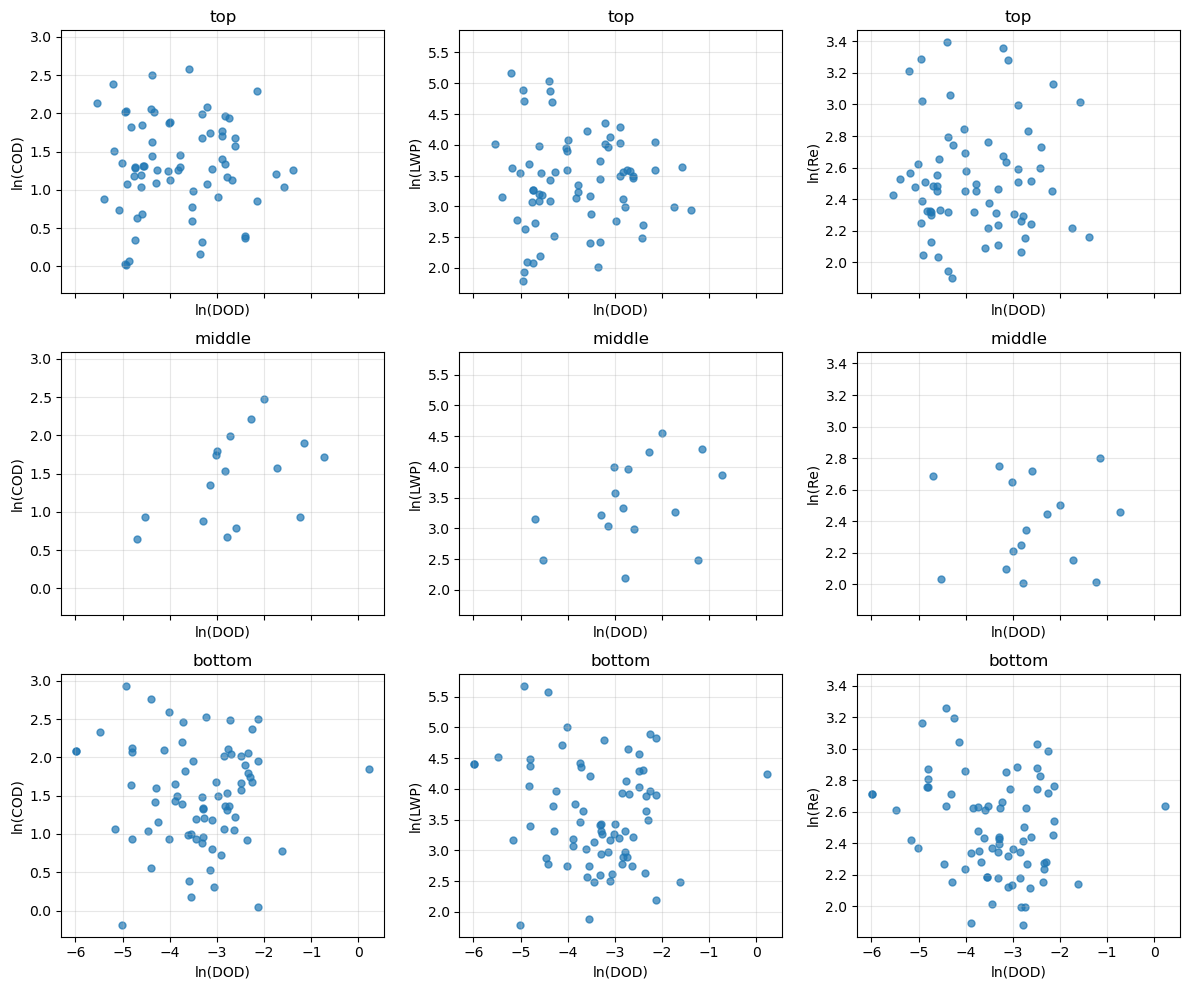

In [27]:
import numpy as np
import matplotlib.pyplot as plt

# ---------- 数据准备 ----------
df_plot = df.copy()
df_plot = df_plot[df_plot["cat"].isin(["top","middle","bottom"])]

for col in ["DOD","COD","LWP","Re"]:
    df_plot = df_plot[df_plot[col] > 0]

df_plot["lnDOD"] = np.log(df_plot["DOD"])
df_plot["lnCOD"] = np.log(df_plot["COD"])
df_plot["lnLWP"] = np.log(df_plot["LWP"])
df_plot["lnRe"]  = np.log(df_plot["Re"])

cats = ["top","middle","bottom"]
yvars = ["lnCOD","lnLWP","lnRe"]
ylabels = ["ln(COD)","ln(LWP)","ln(Re)"]

# ---------- x 轴统一 ----------
xmin = df_plot["lnDOD"].min()
xmax = df_plot["lnDOD"].max()
xpad = 0.05*(xmax-xmin)
xmin -= xpad; xmax += xpad

fig, axes = plt.subplots(3,3, figsize=(12,10), sharex=True)

for j, yvar in enumerate(yvars):

    # 每一列单独的 y 轴范围
    col_min = df_plot[yvar].min()
    col_max = df_plot[yvar].max()
    pad = 0.05*(col_max-col_min)
    col_min -= pad; col_max += pad

    for i, cat in enumerate(cats):

        ax = axes[i,j]
        sub = df_plot[df_plot["cat"]==cat]

        ax.scatter(sub["lnDOD"], sub[yvar],
                   s=25, alpha=0.7)

        ax.set_xlim(xmin, xmax)
        ax.set_ylim(col_min, col_max)

        # 每个子图都设置
        ax.set_xlabel("ln(DOD)")
        ax.set_ylabel(ylabels[j])

        ax.set_title(cat)
        ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

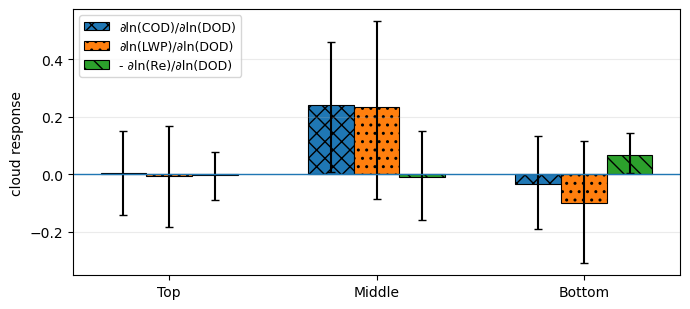

In [30]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import linregress

# =========================
# 1) prepare ln variables
# =========================
df_plot = df.copy()
df_plot = df_plot[df_plot["cat"].isin(["top","middle","bottom"])].copy()

# keep positive + finite only (for log)
for col in ["DOD","COD","LWP","Re"]:
    df_plot = df_plot[np.isfinite(df_plot[col])]
    df_plot = df_plot[df_plot[col] > 0]

lnDOD = np.log(df_plot["DOD"].to_numpy())

# =========================
# 2) slope + bootstrap CI
# =========================
def slope_bootstrap(x, y, nboot=2000, seed=0, min_n=10):
    """
    returns: slope, lo, hi (95% CI)
    """
    m = np.isfinite(x) & np.isfinite(y)
    x = x[m]; y = y[m]
    if x.size < min_n:
        return np.nan, np.nan, np.nan, x.size

    # OLS slope
    slope = linregress(x, y).slope

    rng = np.random.default_rng(seed)
    n = x.size
    boots = np.empty(nboot, float)
    for b in range(nboot):
        ii = rng.integers(0, n, n)
        boots[b] = linregress(x[ii], y[ii]).slope

    lo, hi = np.nanpercentile(boots, [2.5, 97.5])
    return slope, lo, hi, n

cats = ["top","middle","bottom"]

# define the three responses (as in your example)
responses = [
    ("COD",  "∂ln(COD)/∂ln(DOD)",  +1.0),
    ("LWP",  "∂ln(LWP)/∂ln(DOD)",  +1.0),
    ("Re",   "- ∂ln(Re)/∂ln(DOD)", -1.0),  # NOTE: negative sign
]

# compute stats per category
stats = {cat: {} for cat in cats}

for cat in cats:
    sub = df_plot[df_plot["cat"] == cat]
    x = np.log(sub["DOD"].to_numpy())

    for var, label, sgn in responses:
        y = np.log(sub[var].to_numpy())
        slope, lo, hi, n = slope_bootstrap(x, y, nboot=2000, seed=42, min_n=10)
        slope *= sgn
        lo *= sgn
        hi *= sgn

        # ensure lo<=hi after sign flip
        lo2, hi2 = (min(lo, hi), max(lo, hi))

        stats[cat][var] = dict(slope=slope, lo=lo2, hi=hi2, n=n)

# =========================
# 3) plot (like your figure)
# =========================
# bar layout: 3 categories on x, each has 3 bars (COD/LWP/Re)
xpos = np.arange(len(cats))
w = 0.22  # bar width

# hatch styles to mimic your style
hatches = {
    "COD": "xx",
    "LWP": "..",
    "Re":  "\\\\"
}

fig, ax = plt.subplots(figsize=(7.0, 3.2))

for j, (var, label, sgn) in enumerate(responses):
    heights = [stats[c][var]["slope"] for c in cats]
    yerr_lo = [stats[c][var]["slope"] - stats[c][var]["lo"] for c in cats]
    yerr_hi = [stats[c][var]["hi"] - stats[c][var]["slope"] for c in cats]
    yerr = np.vstack([yerr_lo, yerr_hi])

    bars = ax.bar(
        xpos + (j-1)*w, heights, width=w,
        yerr=yerr, capsize=3,
        edgecolor="black", linewidth=0.8,
        label=label
    )
    for b in bars:
        b.set_hatch(hatches[var])

# cosmetics similar to sample
ax.axhline(0, linewidth=1)
ax.set_xticks(xpos)
ax.set_xticklabels(["Top", "Middle", "Bottom"])
ax.set_ylabel("cloud response")

# optional y-limits (comment out if you want auto)
# ax.set_ylim(-0.3, 0.3)

ax.legend(frameon=True, fontsize=9, loc="upper left")
ax.grid(axis="y", alpha=0.25)

# # optional: annotate sample size per category
# for i, cat in enumerate(cats):
#     n_min = min(stats[cat][v]["n"] for v,_,_ in responses)
#     ax.text(i, ax.get_ylim()[0], f"n≥{n_min}", ha="center", va="bottom", fontsize=8)

plt.tight_layout()
plt.show()

OLS results:
top {'COD': (np.float64(0.003438786994518216), np.float64(0.07379468005771325), 68), 'LWP': (np.float64(-0.0059652924184400696), np.float64(0.09238007808780535), 68), 'Re': (np.float64(-0.0040958310347316345), np.float64(0.042326895021989434), 68)}
middle {'COD': (np.float64(0.24010051402068222), np.float64(0.12519685676294762), 16), 'LWP': (np.float64(0.2339189387144677), np.float64(0.15815946772393485), 16), 'Re': (np.float64(-0.008443462166178905), np.float64(0.0684204599373311), 16)}
bottom {'COD': (np.float64(-0.033115002779241176), np.float64(0.07512394043724518), 73), 'LWP': (np.float64(-0.09892695179037801), np.float64(0.09388295847198497), 73), 'Re': (np.float64(0.06662653724122725), np.float64(0.03484579544498431), 73)}
total {'COD': (np.float64(0.027527175584518254), np.float64(0.04652625959457488), 157), 'LWP': (np.float64(-0.013886677391125387), np.float64(0.058058907713885055), 157), 'Re': (np.float64(0.03702890515529319), np.float64(0.023899265938176293), 15

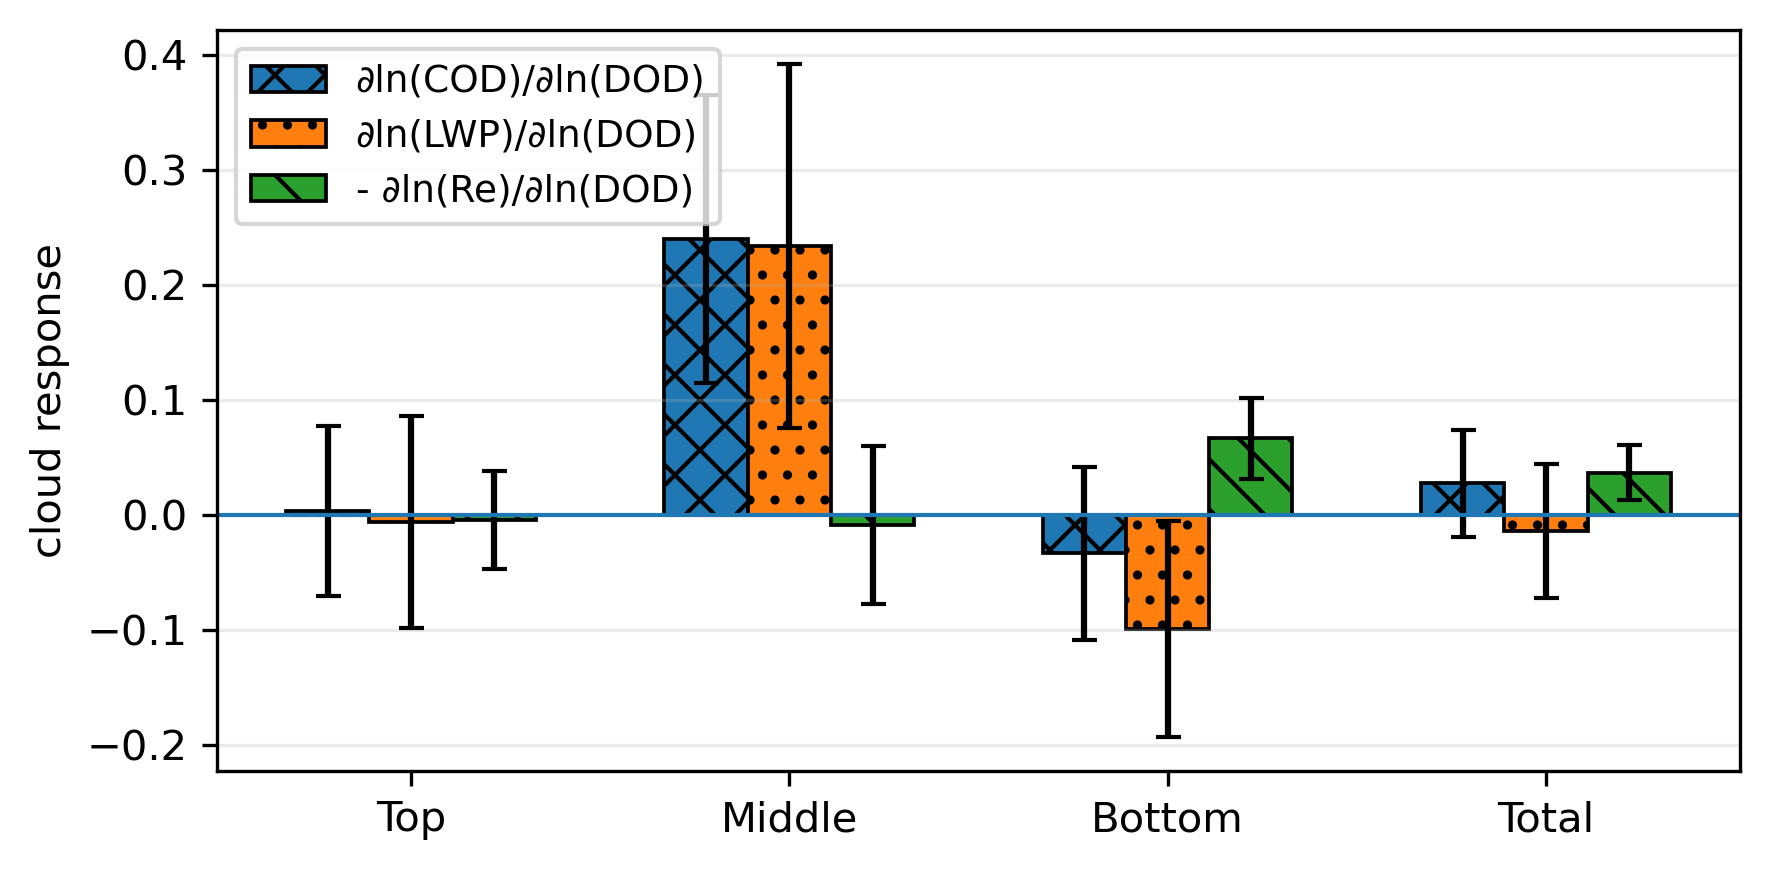

In [37]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import linregress

# =========================================================
# INPUT ASSUMED:
#   df: pandas.DataFrame with columns: cat, DOD, COD, LWP, Re
#       cat includes: top / middle / bottom (others will be dropped)
# =========================================================

# -----------------------
# 1) DATA CLEANING
# -----------------------
cats_main = ["top", "middle", "bottom"]
df0 = df.copy()

# keep needed cats
df0 = df0[df0["cat"].isin(cats_main)].copy()

# numeric + finite
for col in ["DOD", "COD", "LWP", "Re"]:
    df0[col] = pd.to_numeric(df0[col], errors="coerce")
df0 = df0.replace([np.inf, -np.inf], np.nan)

# keep positive values for log
df0 = df0.dropna(subset=["cat", "DOD", "COD", "LWP", "Re"])
df0 = df0[(df0["DOD"] > 0) & (df0["COD"] > 0) & (df0["LWP"] > 0) & (df0["Re"] > 0)].copy()

# -----------------------
# 2) REGRESSION SETTINGS
# -----------------------
cats = ["top", "middle", "bottom", "total"]
responses = [
    ("COD",  +1.0, "∂ln(COD)/∂ln(DOD)"),
    ("LWP",  +1.0, "∂ln(LWP)/∂ln(DOD)"),
    ("Re",   -1.0, "- ∂ln(Re)/∂ln(DOD)"),  # Re uses negative sign
]

# -----------------------
# 3) COMPUTE SLOPES (OLS)
# -----------------------
def fit_ln_slope(sub_df, var, sgn):
    """
    Fit ln(var) = slope * ln(DOD) + intercept
    Return signed slope, stderr, p, r2, n
    """
    x = np.log(sub_df["DOD"].to_numpy())
    y = np.log(sub_df[var].to_numpy())
    slope, intercept, r, p, stderr = linregress(x, y)
    return {
        "slope": slope * sgn,
        "stderr": stderr,     # standard error of slope (not CI)
        "p": p,
        "r2": r**2,
        "n": x.size
    }

results = {}

# per-category
for cat in ["top", "middle", "bottom"]:
    sub = df0[df0["cat"] == cat].copy()
    results[cat] = {}
    for var, sgn, _ in responses:
        results[cat][var] = fit_ln_slope(sub, var, sgn)

# total
sub_all = df0.copy()
results["total"] = {}
for var, sgn, _ in responses:
    results["total"][var] = fit_ln_slope(sub_all, var, sgn)

print("OLS results:")
for c in cats:
    print(c, {v: (results[c][v]["slope"], results[c][v]["stderr"], results[c][v]["n"]) for v,_,_ in responses})

# -----------------------
# 4) PLOT SENSITIVITY BARS
# -----------------------
vars_order = ["COD", "LWP", "Re"]
labels = {var: lab for var, _, lab in responses}
hatches = {"COD": "xx", "LWP": "..", "Re": "\\\\"}

xpos = np.arange(len(cats))
w = 0.22

fig, ax = plt.subplots(figsize=(6, 3),dpi = 300)

for j, v in enumerate(vars_order):
    y = [results[c][v]["slope"] for c in cats]
    e = [results[c][v]["stderr"] for c in cats]

    bars = ax.bar(
        xpos + (j - 1) * w, y, width=w,
        yerr=e, capsize=3,
        edgecolor="black", linewidth=0.9,
        label=labels[v]
    )
    for b in bars:
        b.set_hatch(hatches[v])

ax.axhline(0, linewidth=1)

ax.set_xticks(xpos)
ax.set_xticklabels(["Top", "Middle", "Bottom", "Total"])
ax.set_ylabel("cloud response")

ax.legend(loc="upper left", fontsize=9, frameon=True)
ax.grid(axis="y", alpha=0.25)

# annotate n for each category (same n for all 3 vars because we filtered jointly)
ymin, ymax = ax.get_ylim()
y_text = ymin + 0.04 * (ymax - ymin)
# for i, c in enumerate(cats):
#     n = results[c]["COD"]["n"]
#     ax.text(xpos[i], y_text, f"n={n}", ha="center", va="bottom", fontsize=9)

plt.tight_layout()
plt.show()

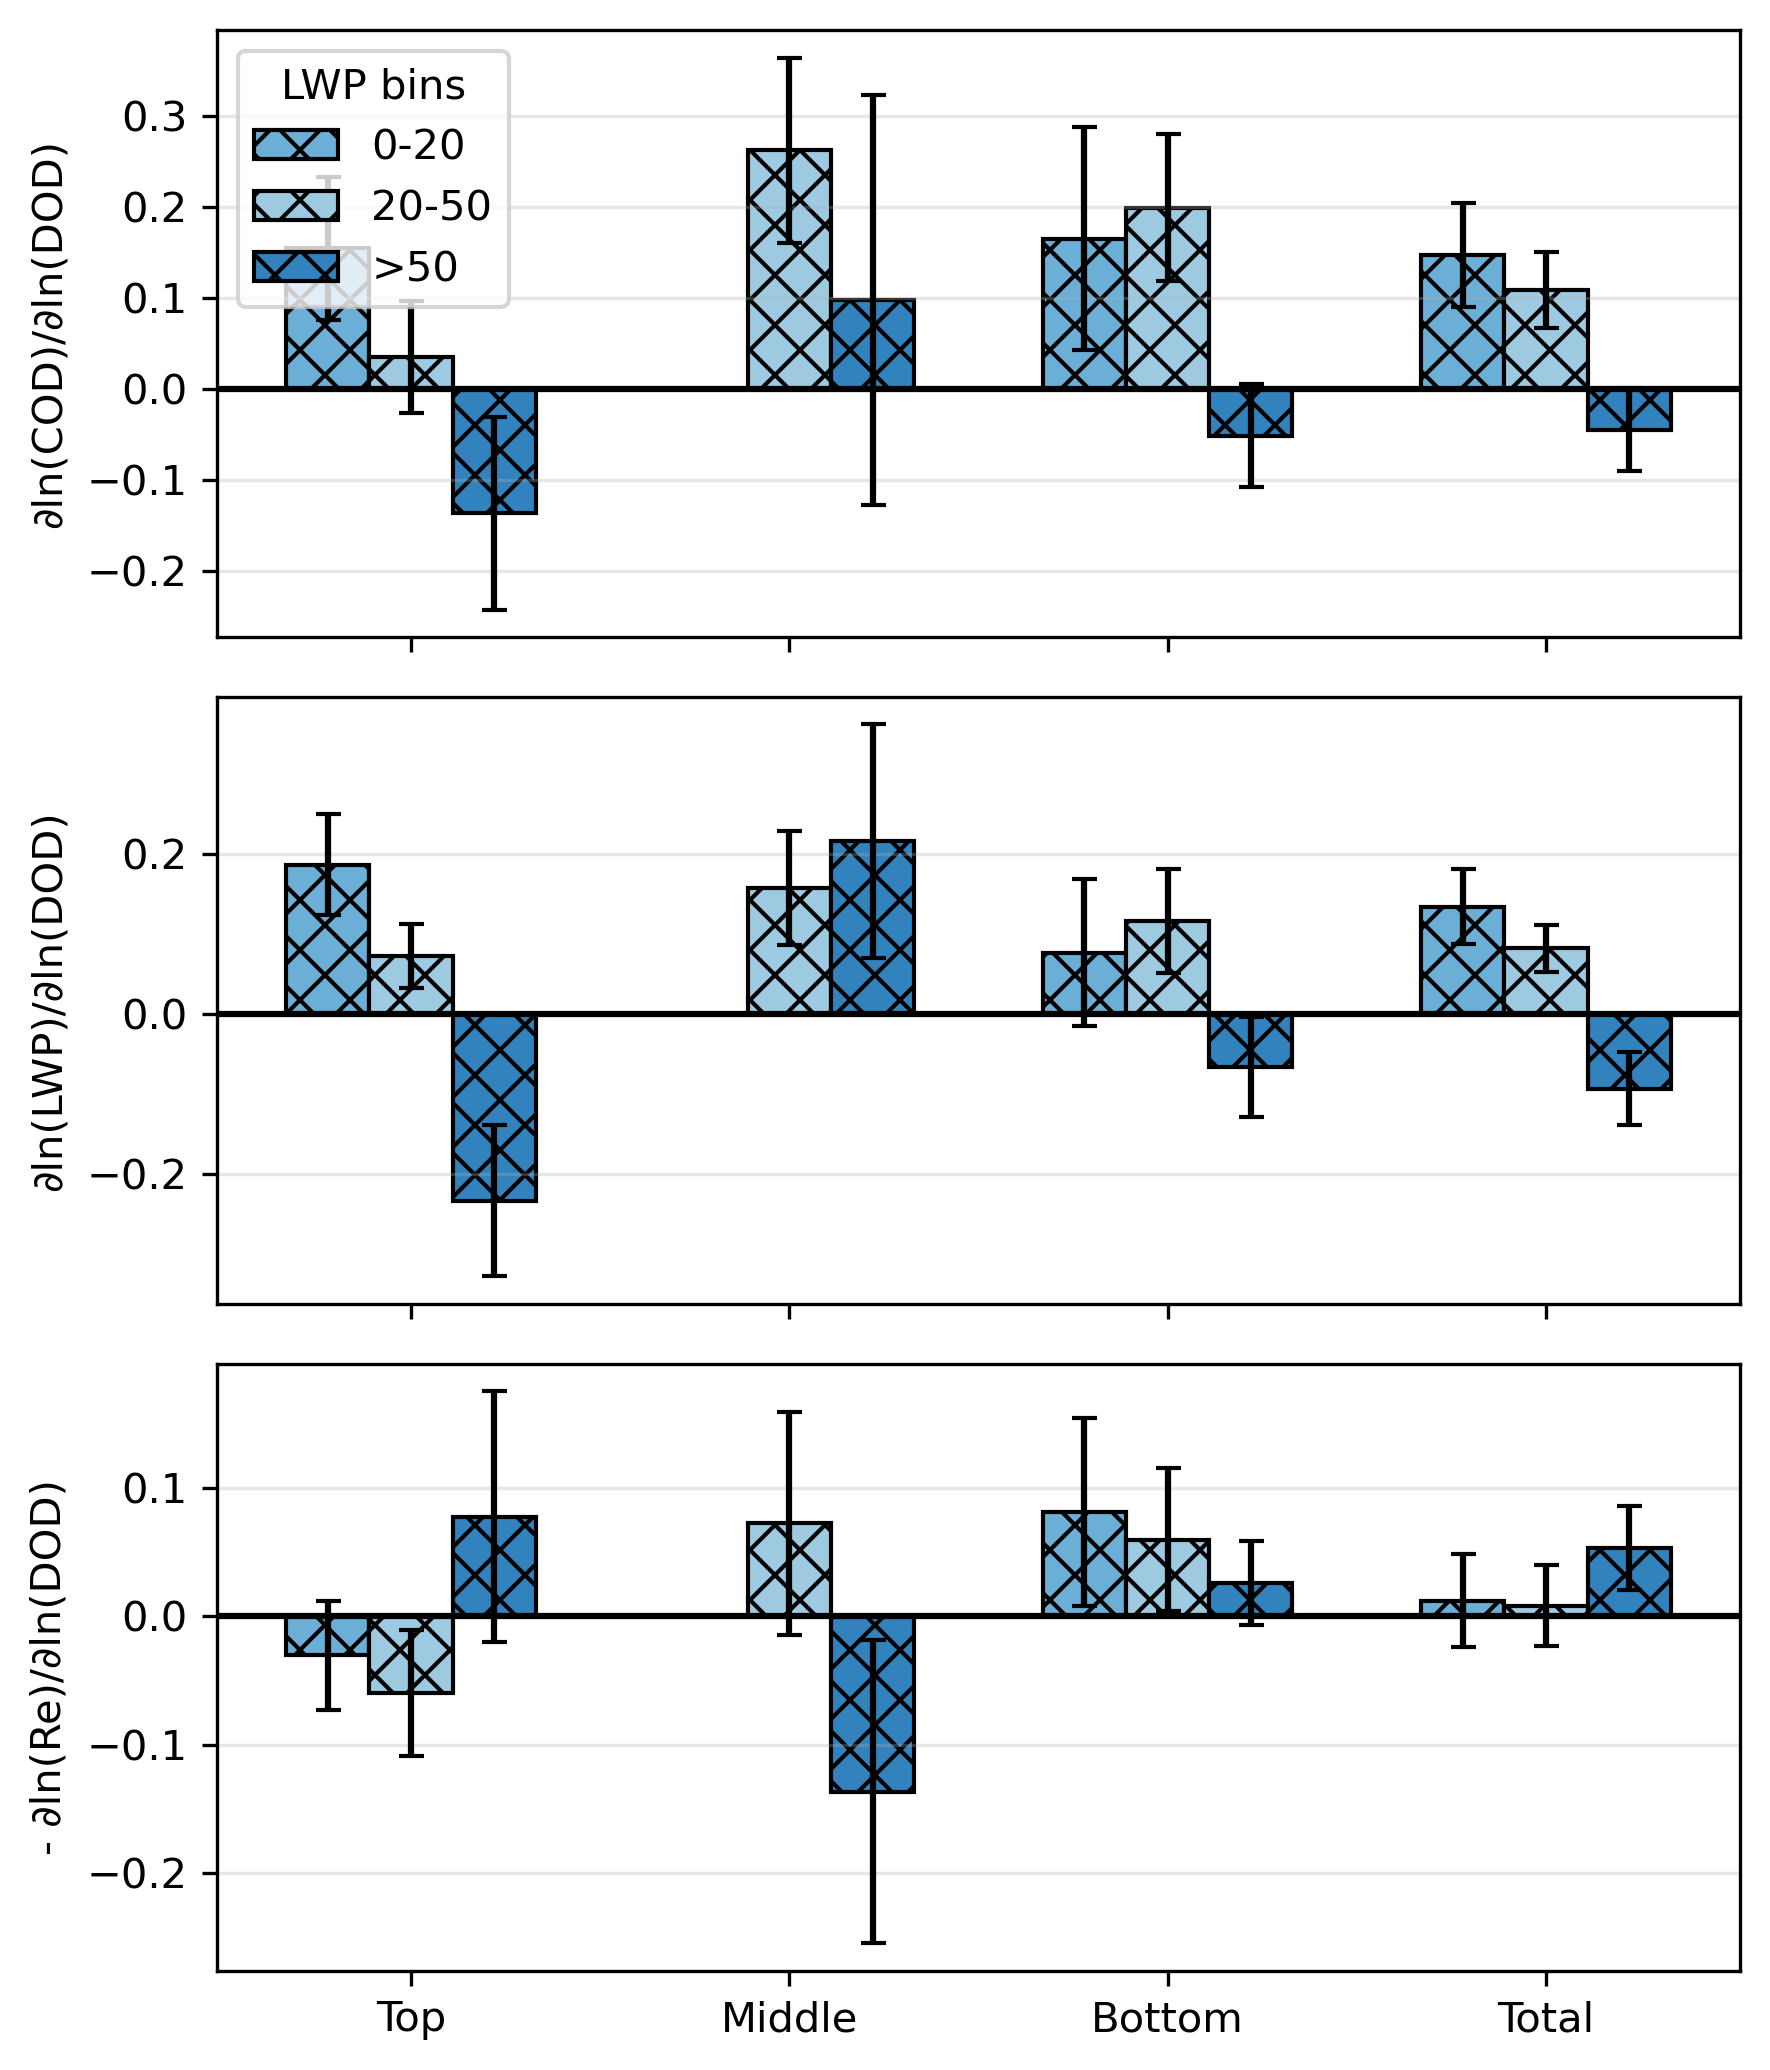

In [40]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import linregress

# -------------------------
# 1) 数据准备
# -------------------------
df0 = df.copy()
df0 = df0[df0["cat"].isin(["top","middle","bottom"])]

# 数值化 + 清理
for col in ["DOD","COD","LWP","Re"]:
    df0[col] = pd.to_numeric(df0[col], errors="coerce")

df0 = df0.dropna(subset=["DOD","COD","LWP","Re"])
df0 = df0[(df0["DOD"]>0)&(df0["COD"]>0)&(df0["LWP"]>0)&(df0["Re"]>0)]

# -------------------------
# 2) LWP 分箱
# -------------------------
bins = [0,20,50,np.inf]
labels = ["0-20","20-50",">50"]
df0["LWP_bin"] = pd.cut(df0["LWP"], bins=bins, labels=labels)

cats = ["top","middle","bottom","total"]
responses = [
    ("COD", 1.0),
    ("LWP", 1.0),
    ("Re", -1.0)
]

# -------------------------
# 3) 计算 sensitivity
# -------------------------
results = {}

for cat in cats:
    if cat == "total":
        df_cat = df0.copy()
    else:
        df_cat = df0[df0["cat"]==cat].copy()

    results[cat] = {}

    for lb in labels:
        sub = df_cat[df_cat["LWP_bin"]==lb]

        if len(sub) < 5:
            continue

        x = np.log(sub["DOD"].values)

        results[cat][lb] = {}

        for var, sgn in responses:
            y = np.log(sub[var].values)
            slope, intercept, r, p, stderr = linregress(x,y)

            results[cat][lb][var] = {
                "slope": slope*sgn,
                "stderr": stderr,
                "n": len(x)
            }

# -------------------------
# 4) 绘图
# -------------------------
colors = ["#6baed6","#9ecae1","#3182bd"]  # 三个LWP bin
hatch = "xx"

xpos = np.arange(len(cats))
w = 0.22

fig, axes = plt.subplots(3,1, figsize=(6,7),dpi=300, sharex=True)

var_names = ["COD","LWP","Re"]
ylabs = [
    "∂ln(COD)/∂ln(DOD)",
    "∂ln(LWP)/∂ln(DOD)",
    "- ∂ln(Re)/∂ln(DOD)"
]

for i, var in enumerate(var_names):

    ax = axes[i]

    for j, lb in enumerate(labels):
        y = []
        e = []

        for cat in cats:
            if lb in results.get(cat, {}):
                y.append(results[cat][lb][var]["slope"])
                e.append(results[cat][lb][var]["stderr"])
            else:
                y.append(np.nan)
                e.append(np.nan)

        bars = ax.bar(
            xpos + (j-1)*w, y, width=w,
            yerr=e, capsize=3,
            color=colors[j],
            edgecolor="black",
            label=lb if i==0 else None
        )

        for b in bars:
            b.set_hatch(hatch)

    ax.axhline(0,color="k")
    ax.set_ylabel(ylabs[i])
    ax.grid(axis="y",alpha=0.3)

axes[-1].set_xticks(xpos)
axes[-1].set_xticklabels(["Top","Middle","Bottom","Total"])

axes[0].legend(title="LWP bins")

plt.tight_layout()
plt.show()